# Testing the Gammapy plugin (instrument VERITAS) for 3ML

Anjana Kaushik Talluri

Current status of things:

We have a working Gammapy plugin for threeML (for the IACT instrument, VERITAS) designed for the likelihood fitting of a point source (specifically, the Crab Nebula) with any 1-D spectrum. This is based on J. Michael's version of the code has a neat Astromodel-Gammapy model converter that also takes care of updating the function parameters each time, so we don't have to do that part by hand. There are certain parts of the gammapy plugin that will have to be generalized (e.g., the coordinates for the exclusion regions are hard-coded). Refer to my notes for more info. 

This notebook includes the following:

1. Fitting of a point source (Crab) with a simple power law spectrum using the updated version of the Gammapy plugin in threeML for VERITAS that incorporates J. Michael's Astromodel-Gammapy model converter. 

2. Fitting of the same point source (Crab) with a simple power law spectrum using the Fermipy plugin in threeML. 

3. Fitting of the same point source (Crab) with a simple power law spectrum using the HAWC plugin in threeML.

4. Joint fitting of the same point source (Crab) with a simple power law spectrum using the Gammapy plugin for VERITAS, the Fermipy plugin, and the HAWC plugin. 

5. Fitting of a point source (Crab) with a log Parabola spectrum using the updated version of the Gammapy plugin in threeML for VERITAS that incorporates J. Michael's Astromodel-Gammapy model converter. 

6. Fitting of the same point source (Crab) with a log Parabola spectrum using the Fermipy plugin in threeML. 

7. Fitting of the same point source (Crab) with a log Parabola  spectrum using the HAWC plugin in threeML.

8. Joint fitting of the same point source (Crab) with a log Parabola spectrum using the Gammapy plugin for VERITAS, the Fermipy plugin, and the HAWC plugin. 

# Import statements

Refer to my notes for info/tips on installing fermipy and the threeML plugins

In [1]:
import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")



import matplotlib.pyplot as plt

import astropy.units as u
from threeML import *
from threeML.io.package_data import get_path_of_data_file



import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")
import shutil
from IPython.display import Image, display
import glob
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt
from astropy.io import fits as pyfits
import scipy as sp


from threeML import *





23:39:12 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=589952;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=138322;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#50\50]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=989753;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=518012;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#71\71]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=452588;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=115558;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py#36\36]8;;\
                  available                                                                                        

23:39:12 INFO      Starting 3ML!                                                                     ]8;id=575259;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=217312;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#31\31]8;;\

23:39:13 WARNING   ROOT minimizer not available                                                ]8;id=871119;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=707350;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py#1345\1345]8;;\

...

23:39:13 WARNING   The cthreeML package is not installed. You will not be able to use plugins which  ]8;id=114739;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=122800;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#79\79]8;;\
                  require the C/C++ interface (currently HAWC)                                                     

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=1166;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=311815;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#129\129]8;;\
                  software installed and configured?                                                               

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=553977;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=673134;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=164705;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=300690;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=264559;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=115619;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

In [2]:
from astromodels import Powerlaw, Log_parabola
from model_converter import SpectralModelGenerator
import astropy.units as u
import numpy as np

# Individual and Joint fit for simple power law spectrum

# Likelihood fitting of a point source (Crab) with a simple power law spectrum using VERITAS in Gammapy

Define the point source and assign the power law spectrum to it. Initialize the parameters (pivot, K, index)

In [3]:

spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things in J. Michael's function
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [4]:

veritas_model = Model(source)
veritas_model.display()
#ene = np.array([1,10,100])



Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [30]:
import model_converter

from GammapyLike import GammapyLike

Let’s create an instance of the plugin

In [31]:
VERITAS = GammapyLike("VERITAS", config_file="config.yaml")

In [32]:
veritas_data = DataList(VERITAS)

In [47]:
veritas_jl = JointLikelihood(veritas_model, veritas_data, verbose=False)
# change verbose to true if you want more info on how it is running

12:59:42 INFO      set the minimizer to minuit                                             ]8;id=160656;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=232749;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Note: JointLikelihood can take one or more models. We simply need to build the data list, create the joint likelihood and run the fit. Refer to the joint fitting section below for an example

In [48]:
veritas_res = veritas_jl.fit()
print(veritas_res)

Best fit values:



,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,(10.000 +/- 0.005) x 10^-7,1 / (cm2 keV s)
crab.spectrum.main.Powerlaw.index,-2.4964 +/- 0.0015,



Correlation matrix:



1.00,-0.01
-0.01,1.00



Values of -log(likelihood) at the minimum:



,-log(likelihood)
VERITAS,30.159114
total,30.159114



Values of statistical measures:



,statistical measures
AIC,64.681865
BIC,67.485267


(                                          value  negative_error  \
crab.spectrum.main.Powerlaw.K      9.999997e-07      999.351979   
crab.spectrum.main.Powerlaw.index -2.496406e+00       -0.001455   

                                   positive_error       error             unit  
crab.spectrum.main.Powerlaw.K          999.902780  999.627379  1 / (cm2 keV s)  
crab.spectrum.main.Powerlaw.index        0.001417    0.001436                   ,          -log(likelihood)
VERITAS         30.159114
total           30.159114)


In [53]:
_ = plot_spectra(veritas_jl.results, flux_unit='erg/(cm2 s TeV)')


processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                               | 0/100 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

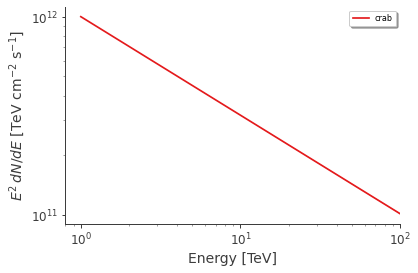

In [119]:
ver_results = veritas_jl.results
ver_results.write_to("crab_veritas_fit.fits", overwrite=True)
ver_results.optimized_model.save("crab_veritas_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    ver_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Likelihood fitting of a point source (Crab) with a simple power law spectrum using the Fermipy plugin in threeML

In [12]:
lat_catalog = FermiLATSourceCatalog()

ra, dec, table = lat_catalog.search_around_source("Crab", radius=0.004)

table

Trying https://heasarc.gsfc.nasa.gov/cgi-bin/vo/cone/coneGet.pl?table=fermilpsc&


name,source_type,short_source_type,ra,dec,assoc_name,tevcat_assoc,Search_Offset
,,,deg,deg,,,
object,str32,object,float64,float64,object,object,float64
4FGL J0534.5+2200,"pulsar, identified by pulsations",PSR,83.6367,22.0149,PSR J0534+2200,Crab pulsar,0.2119


In [36]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [37]:
fermi_model = Model(source)
fermi_model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [38]:
ra = 83.63
dec = 22.01

In [39]:
# Download data from Jan 01 2010 to February 1 2010

tstart = "2010-01-01 00:00:00"
tstop = "2010-02-01 00:00:00"

# Note that this will understand if you already download these files, and will
# not do it twice unless you change your selection or the outdir

evfile, scfile = download_LAT_data(
    ra,
    dec,
    20.0,
    tstart,
    tstop,
    time_type="Gregorian",
    destination_directory="Crab_data",
)

00:38:21 INFO      Query parameters:                                                       ]8;id=785446;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=715908;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#262\262]8;;\

         INFO                          coordfield = 83.6300,22.0100                        ]8;id=183727;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=992669;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         coordsystem = J2000                                  ]8;id=916520;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=677085;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          shapefield = 20.0                                   ]8;id=920345;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=723119;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                           timefield = 2010-01-01 00:00:00,2010-02-01         ]8;id=774197;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=477318;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\
                  00:00:00                                                                                         

...

         INFO                         energyfield = 30.000,1000000.000                     ]8;id=214167;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=941870;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO              photonOrExtendedOrNone = Photon                                 ]8;id=49379;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=585113;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         destination = query                                  ]8;id=686840;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=535058;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          spacecraft = checked                                ]8;id=270145;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=163305;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO      Query ID: e94fe495b65679baa926097eebf7f7fd                              ]8;id=791526;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=730551;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#271\271]8;;\

In [40]:
import fermipy

In [41]:
config = FermipyLike.get_basic_config(
    evfile=evfile,
    scfile=scfile,
    ra=ra,
    dec=dec,
    fermipy_verbosity=1,
    fermitools_chatter=0,
)

# See what we just got

config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

In [42]:
LAT = FermipyLike("LAT", config)
config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
fileio:
  outdir: __001f42fcf467f6472a624190907310b5
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
fileio:
 outdir: __001f42fcf467f6472a624190907310b5
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

In [44]:

fermi_data = DataList(LAT)
fermi_jl = JointLikelihood(fermi_model, fermi_data, verbose=True)
fermi_res = fermi_jl.fit()
print(fermi_res)

00:39:14 INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=736752;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=916982;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py#105\105]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


00:39:24 INFO      set the minimizer to minuit                                             ]8;id=166944;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=629459;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

         INFO      trial values: 0.21436,-2.1476 -> logL = -118034.455                     ]8;id=509386;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=873568;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1010\1010]8;;\

         INFO      trial values: 0.21537,-2.1476 -> logL = -118034.463                     ]8;id=625225;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=679102;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1010\1010]8;;\

...


Values of -log(likelihood) at the minimum:



,-log(likelihood)
LAT,118034.455199
total,118034.455199



Values of statistical measures:



,statistical measures
AIC,236072.910447
BIC,236093.687186


(                                          value  negative_error  \
crab.spectrum.main.Powerlaw.K      1.638141e-09        1.306089   
crab.spectrum.main.Powerlaw.index -2.147645e+00       -0.017561   

                                   positive_error     error             unit  
crab.spectrum.main.Powerlaw.K            2.058730  1.682410  1 / (cm2 keV s)  
crab.spectrum.main.Powerlaw.index        0.017414  0.017488                   ,        -log(likelihood)
LAT       118034.455199
total     118034.455199)


In [54]:
_ = plot_spectra(fermi_jl.results, flux_unit='erg/(cm2 s TeV)')

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                               | 0/100 [00:00<?, ?it/s]

# Plot the SED

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

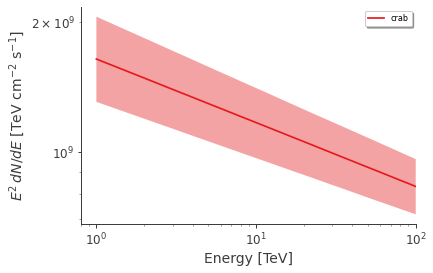

In [120]:
fermi_results = fermi_jl.results
fermi_results.write_to("crab_fermi_fit.fits", overwrite=True)
fermi_results.optimized_model.save("crab_fermi_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    fermi_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Likelihood fitting of a point source (Crab) with a simple power law spectrum using HAWC plugin in threeML

In [24]:
from hawc_hal import HAL, HealpixConeROI

import os

os.environ['OMP_NUM_THREADS'] = "1"
os.environ['MKL_NUM_THREADS'] = "1"

In [25]:
import requests
import shutil
import os


def get_hawc_file(filename, odir="./", overwrite=False):

    if overwrite or not os.path.exists(odir + filename):
        url = "https://data.hawc-observatory.org/datasets/crab_data/public_data/crab_2017/"

        req = requests.get(url + filename, verify=False, stream=True)
        req.raw.decode_content = True
        with open(odir + filename, "wb") as f:
            shutil.copyfileobj(req.raw, f)

    return odir + filename


maptree = "HAWC_9bin_507days_crab_data.hd5"
response = "HAWC_9bin_507days_crab_response.hd5"
odir = "./"


maptree = get_hawc_file(maptree, odir)
response = get_hawc_file(response, odir)

assert os.path.exists(maptree)
assert os.path.exists(response)



In [26]:
%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)

In [27]:
hawc.display()

00:14:06 INFO      Region of Interest:                                                                   ]8;id=258670;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=906851;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#270\270]8;;\

         INFO      -------------------                                                                   ]8;id=864960;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=296745;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#271\271]8;;\

         INFO      HealpixConeROI: Center (R.A., Dec) = (83.630, 22.020), data radius =      ]8;id=787987;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/region_of_interest/healpix_cone_roi.py\healpix_cone_roi.py]8;;\:]8;id=647688;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/region_of_interest/healpix_cone_roi.py#87\87]8;;\
                  3.000 deg, model radius: 3.000 deg                                                               

         INFO                                                                                            ]8;id=895431;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=836920;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#274\274]8;;\

         INFO      Flat sky projection:                                                                  ]8;id=100114;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=499313;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#275\275]8;;\

...

         INFO      Total data size: 1.38 Mb                                                         ]8;id=944239;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/maptree/map_tree.py\map_tree.py]8;;\:]8;id=527068;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/maptree/map_tree.py#151\151]8;;\

         INFO                                                                                            ]8;id=96232;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=933817;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#294\294]8;;\

         INFO      Active energy/nHit planes (9):                                                        ]8;id=682164;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=315100;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#295\295]8;;\

         INFO      -------------------------------                                                       ]8;id=57963;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=269116;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#296\296]8;;\

         INFO      ['1', '2', '3', '4', '5', '6', '7', '8', '9']                                         ]8;id=608578;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=43186;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#297\297]8;;\

In [28]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

hawc_model = Model(source)
hawc_model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [45]:
%%time

hawc_data = DataList(hawc)

hawc_jl = JointLikelihood(hawc_model, hawc_data)
hawc_model.display()

hawc_res = hawc_jl.fit()

print(hawc_res)

00:43:09 INFO      set the minimizer to minuit                                             ]8;id=663154;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=461424;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                        value min_value max_value  \
crab.spectrum.main.Powerlaw.K      999.999904       0.0    1000.0   
crab.spectrum.main.Powerlaw.index   -2.505502     -10.0      10.0   

                                             unit  
crab.spectrum.main.Powerlaw.K      TeV-1 s-1 cm-2  
crab.spectrum.main.Powerlaw.index                  

Fixed parameters (4):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

Best fit values:



,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,(10.0000 +/- 0.0004) x 10^-7,1 / (cm2 keV s)
crab.spectrum.main.Powerlaw.index,-2.5055 +/- 0.0006,



Correlation matrix:



...


Values of -log(likelihood) at the minimum:



,-log(likelihood)
HAWC,18836.838461
total,18836.838461



Values of statistical measures:



,statistical measures
AIC,37677.677061
BIC,37696.407860


(                                          value  negative_error  \
crab.spectrum.main.Powerlaw.K      1.000000e-06      999.950604   
crab.spectrum.main.Powerlaw.index -2.505499e+00       -0.000554   

                                   positive_error       error             unit  
crab.spectrum.main.Powerlaw.K          999.993205  999.971904  1 / (cm2 keV s)  
crab.spectrum.main.Powerlaw.index        0.000542    0.000548                   ,        -log(likelihood)
HAWC       18836.838461
total      18836.838461)
CPU times: user 696 ms, sys: 23.8 ms, total: 719 ms
Wall time: 722 ms


# Plot the SED

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

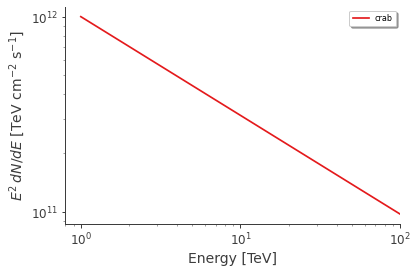

In [121]:
hawc_results = hawc_jl.results
hawc_results.write_to("crab_hawc_fit.fits", overwrite=True)
hawc_results.optimized_model.save("crab_hawc_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    hawc_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Joint fit powerlaw spectrum

In [57]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [58]:

joint_p_model = Model(source)
joint_p_model.display()
#ene = np.array([1,10,100])



Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [59]:
%%time

joint_p_data = DataList(VERITAS, LAT, hawc)

joint_p_jl = JointLikelihood(joint_p_model, joint_p_data)
joint_p_model.display()

joint_p_res = joint_p_jl.fit()

print(joint_p_res)

18:01:46 INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=279034;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=269961;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py#105\105]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


18:01:57 INFO      set the minimizer to minuit                                             ]8;id=223570;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=330494;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (4):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

Best fit values:



...


Values of -log(likelihood) at the minimum:



,-log(likelihood)
HAWC,19034.054764
LAT,118097.402284
VERITAS,236.899634
total,137368.356683



Values of statistical measures:



,statistical measures
AIC,274740.713403
BIC,274762.104670


(                                          value  negative_error  \
crab.spectrum.main.Powerlaw.K      1.784533e-08       17.061521   
crab.spectrum.main.Powerlaw.index -2.326944e+00       -0.002360   

                                   positive_error      error             unit  
crab.spectrum.main.Powerlaw.K           18.713269  17.887395  1 / (cm2 keV s)  
crab.spectrum.main.Powerlaw.index        0.002252   0.002306                   ,          -log(likelihood)
HAWC         19034.054764
LAT         118097.402284
VERITAS        236.899634
total       137368.356683)
CPU times: user 10.3 s, sys: 595 ms, total: 10.9 s
Wall time: 14.1 s


processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                               | 0/500 [00:00<?, ?it/s]

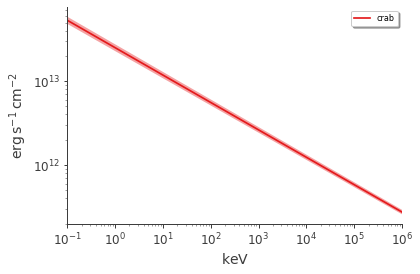

In [63]:
plot_spectra(joint_p_jl.results, ene_min=0.1, ene_max=1e6, num_ene=500, 
                          flux_unit='erg / (cm2 s)')

# Plot the SED

In [97]:
presults = joint_p_jl.results
presults.write_to("crab_joint_p_fit.fits", overwrite=True)
presults.optimized_model.save("crab_joint_p_fit.yml", overwrite=True)

In [98]:
fig, ax = plt.subplots()

plot_spectra(
    presults,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

Text(0.5, 0, 'Energy [TeV]')

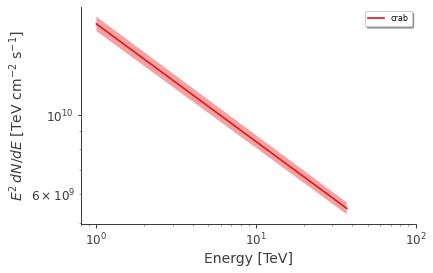

In [99]:
plt.show()

Plot the SED in a single plot for each of the fits as well as the joint fit

In [124]:
fig, ax = plt.subplots()

plot_spectra(
    ver_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")



#fig, ax = plt.subplots()

plot_spectra(
    fermi_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)


#fig, ax = plt.subplots()

plot_spectra(
    hawc_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)

ax.set_


#fig, ax = plt.subplots()

plot_spectra(
    presults,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)



processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

Text(0.5, 0, 'Energy [TeV]')

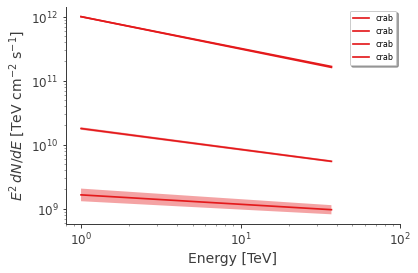

In [125]:
plt.show()

----------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------

# Individual and Joint fit for log parabola spectrum

In [137]:
# Define model
spectrum = Log_parabola()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 7 * u.TeV
spectrum.piv.fix = True

spectrum.K = 1e-14 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.bounds = (1e-35, 1e-10) / (
    u.TeV * u.cm**2 * u.s
)  # without units energies would be in keV

spectrum.alpha = -2.5  # log parabolic alpha (index)
spectrum.alpha.bounds = (-4.0, 2.0)

spectrum.beta = 0  # log parabolic beta (curvature)
spectrum.beta.bounds = (-1.0, 1.0)

joint_lp_model = Model(source)

joint_lp_model.display(complete=True)

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (3):
--------------------

                                      value min_value max_value  \
crab.spectrum.main.Log_parabola.K       0.0       0.0       0.0   
crab.spectrum.main.Log_parabola.alpha  -2.5      -4.0       2.0   
crab.spectrum.main.Log_parabola.beta    0.0      -1.0       1.0   

                                                 unit  
crab.spectrum.main.Log_parabola.K      keV-1 s-1 cm-2  
crab.spectrum.main.Log_parabola.alpha                  
crab.spectrum.main.Log_parabola.beta                   

Fixed parameters (3):
---------------------

                                            value min_value max_value unit
crab.position.ra                            83.63       0.0     360.0  deg
crab.position.dec                           22.01     -90.0      90.0  deg
crab.spectrum.main.Log_parabola.piv  7000000000.0      None      None  keV

Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

# VERITAS with Gammapy

In [127]:
veritas_model = Model(source)
veritas_model.display()

import model_converter
from GammapyLike import GammapyLike


VERITAS = GammapyLike("VERITAS", config_file="config.yaml")
veritas_data = DataList(VERITAS)
veritas_jl = JointLikelihood(veritas_model, veritas_data, verbose=False)
veritas_res = veritas_jl.fit()
print(veritas_res)

ver_lp_results = veritas_jl.results
#ver_results.write_to("crab_veritas_fit.fits", overwrite=True)
#ver_results.optimized_model.save("crab_veritas_fit.yml", overwrite=True)



Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (3):
--------------------

                                      value min_value max_value  \
crab.spectrum.main.Log_parabola.K       0.0       0.0       0.0   
crab.spectrum.main.Log_parabola.alpha  -2.5      -4.0       2.0   
crab.spectrum.main.Log_parabola.beta    0.0      -1.0       1.0   

                                                 unit  
crab.spectrum.main.Log_parabola.K      keV-1 s-1 cm-2  
crab.spectrum.main.Log_parabola.alpha                  
crab.spectrum.main.Log_parabola.beta                   

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

22:57:32 INFO      set the minimizer to minuit                                             ]8;id=257498;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=720259;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Best fit values:



,result,unit
parameter,,
crab.spectrum.main.Log_parabola.K,(8.2 -2.0 +2.7) x 10^-23,1 / (cm2 keV s)
crab.spectrum.main.Log_parabola.alpha,-3.57 +/- 0.25,
crab.spectrum.main.Log_parabola.beta,(2.2 +/- 0.5) x 10^-1,



Correlation matrix:



...


Values of -log(likelihood) at the minimum:



,-log(likelihood)
VERITAS,15.434422
total,15.434422



Values of statistical measures:



,statistical measures
AIC,37.618844
BIC,41.619401


(                                              value  negative_error  \
crab.spectrum.main.Log_parabola.K      8.151981e-23   -1.829521e-23   
crab.spectrum.main.Log_parabola.alpha -3.569353e+00   -2.155642e-01   
crab.spectrum.main.Log_parabola.beta   2.191569e-01   -5.258845e-02   

                                       positive_error         error  \
crab.spectrum.main.Log_parabola.K        2.793855e-23  2.311688e-23   
crab.spectrum.main.Log_parabola.alpha    2.528509e-01  2.342075e-01   
crab.spectrum.main.Log_parabola.beta     4.455742e-02  4.857293e-02   

                                                  unit  
crab.spectrum.main.Log_parabola.K      1 / (cm2 keV s)  
crab.spectrum.main.Log_parabola.alpha                   
crab.spectrum.main.Log_parabola.beta                    ,          -log(likelihood)
VERITAS         15.434422
total           15.434422)


processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

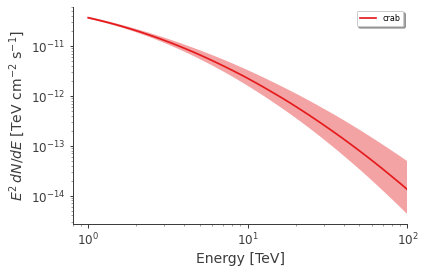

In [128]:
fig, ax = plt.subplots()

plot_spectra(
    ver_lp_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Fermi

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (3):
--------------------

                                          value min_value max_value  \
crab.spectrum.main.Log_parabola.K           0.0       0.0       0.0   
crab.spectrum.main.Log_parabola.alpha -2.762749      -4.0       2.0   
crab.spectrum.main.Log_parabola.beta   0.033872      -1.0       1.0   

                                                 unit  
crab.spectrum.main.Log_parabola.K      keV-1 s-1 cm-2  
crab.spectrum.main.Log_parabola.alpha                  
crab.spectrum.main.Log_parabola.beta                   

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

23:03:29 INFO      Query parameters:                                                       ]8;id=545121;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=404992;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#262\262]8;;\

         INFO                          coordfield = 83.6300,22.0100                        ]8;id=169043;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=181830;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         coordsystem = J2000                                  ]8;id=486750;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=491061;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          shapefield = 20.0                                   ]8;id=69784;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=612401;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

...


Values of statistical measures:



,statistical measures
AIC,236066.057856
BIC,236097.222939


(                                              value  negative_error  \
crab.spectrum.main.Log_parabola.K      7.599109e-23   -2.705359e-23   
crab.spectrum.main.Log_parabola.alpha -2.762751e+00   -9.410812e-02   
crab.spectrum.main.Log_parabola.beta   3.387229e-02   -5.180748e-03   

                                       positive_error         error  \
crab.spectrum.main.Log_parabola.K        4.301209e-23  3.503284e-23   
crab.spectrum.main.Log_parabola.alpha    9.528053e-02  9.469432e-02   
crab.spectrum.main.Log_parabola.beta     5.267760e-03  5.224254e-03   

                                                  unit  
crab.spectrum.main.Log_parabola.K      1 / (cm2 keV s)  
crab.spectrum.main.Log_parabola.alpha                   
crab.spectrum.main.Log_parabola.beta                    ,        -log(likelihood)
LAT       118030.028878
total     118030.028878)


processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

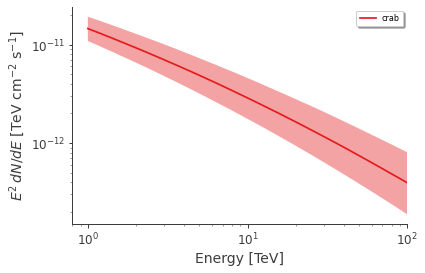

In [130]:
fermi_model = Model(source)
fermi_model.display()
ra = 83.63
dec = 22.01


# Download data from Jan 01 2010 to February 1 2010

tstart = "2010-01-01 00:00:00"
tstop = "2010-02-01 00:00:00"

# Note that this will understand if you already download these files, and will
# not do it twice unless you change your selection or the outdir

evfile, scfile = download_LAT_data(
    ra,
    dec,
    20.0,
    tstart,
    tstop,
    time_type="Gregorian",
    destination_directory="Crab_data",
)

import fermipy

config = FermipyLike.get_basic_config(
    evfile=evfile,
    scfile=scfile,
    ra=ra,
    dec=dec,
    fermipy_verbosity=1,
    fermitools_chatter=0,
)

# See what we just got

config.display()

LAT = FermipyLike("LAT", config)
config.display()



fermi_data = DataList(LAT)
fermi_jl = JointLikelihood(fermi_model, fermi_data, verbose=False)
fermi_res = fermi_jl.fit()
print(fermi_res)


fermi_lp_results = fermi_jl.results
#fermi_results.write_to("crab_fermi_fit.fits", overwrite=True)
#fermi_results.optimized_model.save("crab_fermi_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    fermi_lp_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# HAWC

In [131]:
%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)



%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)


hawc.display()





In [138]:
hawc_model = Model(source)
hawc_model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (3):
--------------------

                                      value min_value max_value  \
crab.spectrum.main.Log_parabola.K       0.0       0.0       0.0   
crab.spectrum.main.Log_parabola.alpha  -2.5      -4.0       2.0   
crab.spectrum.main.Log_parabola.beta    0.0      -1.0       1.0   

                                                 unit  
crab.spectrum.main.Log_parabola.K      keV-1 s-1 cm-2  
crab.spectrum.main.Log_parabola.alpha                  
crab.spectrum.main.Log_parabola.beta                   

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [140]:
%%time

hawc_data = DataList(hawc)

hawc_jl = JointLikelihood(hawc_model, hawc_data)
hawc_model.display()

hawc_res = hawc_jl.fit()

print(hawc_res)

11:26:54 INFO      set the minimizer to minuit                                             ]8;id=394625;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=125473;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (3):
--------------------

                                          value min_value max_value  \
crab.spectrum.main.Log_parabola.K           0.0       0.0       0.0   
crab.spectrum.main.Log_parabola.alpha -2.646606      -4.0       2.0   
crab.spectrum.main.Log_parabola.beta   0.103301      -1.0       1.0   

                                                 unit  
crab.spectrum.main.Log_parabola.K      keV-1 s-1 cm-2  
crab.spectrum.main.Log_parabola.alpha                  
crab.spectrum.main.Log_parabola.beta                   

Fixed parameters (4):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

Best fit values:



,result,unit
parameter,,
crab.spectrum.main.Log_parabola.K,(2.53 +/- 0.06) x 10^-22,1 / (cm2 keV s)
crab.spectrum.main.Log_parabola.alpha,-2.647 +/- 0.018,
crab.spectrum.main.Log_parabola.beta,(1.03 +/- 0.14) x 10^-1,



Correlation matrix:



...


Values of -log(likelihood) at the minimum:



,-log(likelihood)
HAWC,18776.233061
total,18776.233061



Values of statistical measures:



,statistical measures
AIC,37558.466400
BIC,37586.562529


(                                              value  negative_error  \
crab.spectrum.main.Log_parabola.K      2.534889e-22   -6.236175e-24   
crab.spectrum.main.Log_parabola.alpha -2.646614e+00   -1.823650e-02   
crab.spectrum.main.Log_parabola.beta   1.033072e-01   -1.428940e-02   

                                       positive_error         error  \
crab.spectrum.main.Log_parabola.K        6.440394e-24  6.338285e-24   
crab.spectrum.main.Log_parabola.alpha    1.817042e-02  1.820346e-02   
crab.spectrum.main.Log_parabola.beta     1.451951e-02  1.440445e-02   

                                                  unit  
crab.spectrum.main.Log_parabola.K      1 / (cm2 keV s)  
crab.spectrum.main.Log_parabola.alpha                   
crab.spectrum.main.Log_parabola.beta                    ,        -log(likelihood)
HAWC       18776.233061
total      18776.233061)
CPU times: user 862 ms, sys: 24.7 ms, total: 887 ms
Wall time: 890 ms


processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

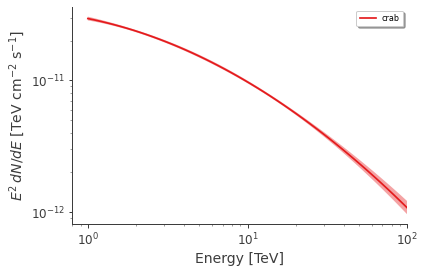

In [141]:
hawc_lp_results = hawc_jl.results
#fermi_results.write_to("crab_fermi_fit.fits", overwrite=True)
#fermi_results.optimized_model.save("crab_fermi_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    hawc_lp_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Joint fit with log Parabola for a point source

In [142]:
%%time

joint_lp_data = DataList(VERITAS, LAT, hawc)

joint_lp_jl = JointLikelihood(joint_lp_model, joint_lp_data)
joint_lp_model.display()

joint_lp_res = joint_lp_jl.fit()

print(joint_lp_res)

11:27:30 INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=389661;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=443998;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py#105\105]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


11:27:43 INFO      set the minimizer to minuit                                             ]8;id=318594;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=541649;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (3):
--------------------

                                          value min_value max_value  \
crab.spectrum.main.Log_parabola.K           0.0       0.0       0.0   
crab.spectrum.main.Log_parabola.alpha -2.646614      -4.0       2.0   
crab.spectrum.main.Log_parabola.beta   0.103307      -1.0       1.0   

                                                 unit  
crab.spectrum.main.Log_parabola.K      keV-1 s-1 cm-2  
crab.spectrum.main.Log_parabola.alpha                  
crab.spectrum.main.Log_parabola.beta                   

Fixed parameters (4):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

Best fit values:



...


Values of -log(likelihood) at the minimum:



,-log(likelihood)
HAWC,18792.827749
LAT,118040.538874
VERITAS,30.919466
total,136864.286089



Values of statistical measures:



,statistical measures
AIC,273734.572251
BIC,273766.659134


(                                              value  negative_error  \
crab.spectrum.main.Log_parabola.K      2.252065e-22   -2.784951e-24   
crab.spectrum.main.Log_parabola.alpha -2.614145e+00   -9.357026e-03   
crab.spectrum.main.Log_parabola.beta   3.002213e-02   -9.432103e-04   

                                       positive_error         error  \
crab.spectrum.main.Log_parabola.K        2.915042e-24  2.849996e-24   
crab.spectrum.main.Log_parabola.alpha    9.248729e-03  9.302877e-03   
crab.spectrum.main.Log_parabola.beta     9.355470e-04  9.393787e-04   

                                                  unit  
crab.spectrum.main.Log_parabola.K      1 / (cm2 keV s)  
crab.spectrum.main.Log_parabola.alpha                   
crab.spectrum.main.Log_parabola.beta                    ,          -log(likelihood)
HAWC         18792.827749
LAT         118040.538874
VERITAS         30.919466
total       136864.286089)
CPU times: user 10.4 s, sys: 725 ms, total: 11.1 s
Wall time: 15.4 s


processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                               | 0/500 [00:00<?, ?it/s]

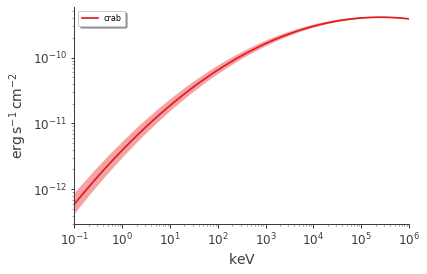

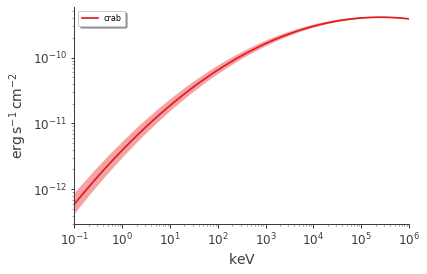

In [143]:
plot_spectra(joint_lp_jl.results, ene_min=0.1, ene_max=1e6, num_ene=500, 
                          flux_unit='erg / (cm2 s)')

# Plot the SED

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

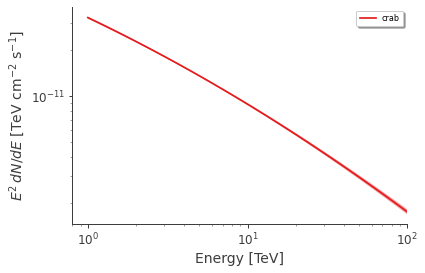

In [144]:
fig, ax = plt.subplots()

plot_spectra(
    joint_lp_jl.results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

Overlaying the Veritas 2015 fit with the parameters: log parabola with norm K = 3.75e-11, alpha = -2.467, beta = -0.16. The equation is 

$$ dN/dE dA dt =  f_{0} (\frac{E}{E_{0}})^ {-\alpha + \beta log(E/E_{0})}$$


where  f_0 is K, E_0 is 1 TeV. 

So, 

$$ dN/dE dA dt = K (\frac{E}{E_{0}})^ {-\alpha + (\beta log(E/E_{0}))}$$


Reference: https://veritas.sao.arizona.edu/GammaWiki/images/c/c4/Meagher_icrc2015_Crab_Nebula_v3_2.pdf

1 keV = 10^(-9) TeV

1 TeV = 10^9 keV 

In [104]:
E = np.array([1,100,1000]) * u.TeV

alpha = -2.467
beta = -0.16

K = 3.755e-11 / (u.TeV* u.cm**2 * u.s) 
E_0 = 1 * u.TeV


def return_logP(E):
    E_norm = E/E_0
    print(E_norm)
    exp = -alpha + (beta* np.log10(E_norm))
    y = K * (E_norm ** exp)
    return y

y_logP=[]
for ene in E:
    y_logP.append(return_logP(ene))

    



1.0
100.0
1000.0


In [101]:
y_logP_val =[]
E_val =[]

for i in range(len(E)):
    y_logP_val.append(y_logP[i].value)
    E_val.append(E[i].value)

In [115]:
E = np.linspace(1,100,1000)

alpha = -2.467
beta = -0.16

K = 3.755e-11 
E_0 = 1


def return_logP(E):
    E_norm = E/E_0
    #print(E_norm)
    exp = -alpha + (beta* np.log10(E_norm))
    y = K * (E_norm ** exp)
    return y

y_logP=[]
for ene in E:
    y_logP.append(return_logP(ene))

    

print(len(y_logP))
print(len(E))


1000
1000


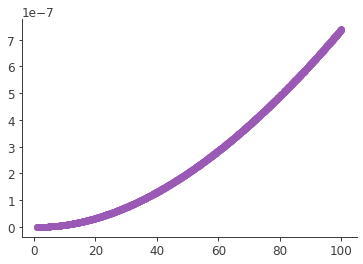

In [116]:
plt.scatter(E, y_logP)
plt.show()

# Plot the SED and overlay the log parabola VERITAS 2015 fit

In [145]:
results = joint_lp_jl.results
results.write_to("crab_joint_lp_fit.fits", overwrite=True)
results.optimized_model.save("crab_joint_lp_fit.yml", overwrite=True)

In [117]:
fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

Text(0.5, 0, 'Energy [TeV]')

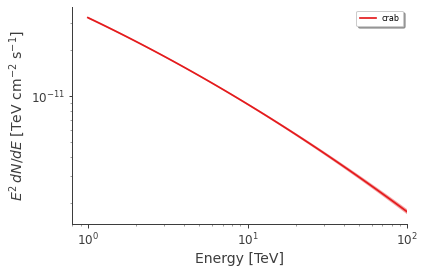

In [118]:
plt.show()

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

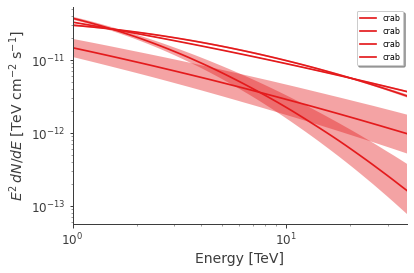

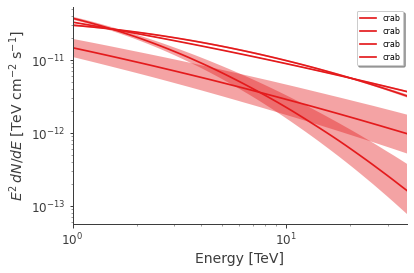

In [146]:
fig, ax = plt.subplots()

plot_spectra(
    ver_lp_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")



#fig, ax = plt.subplots()

plot_spectra(
    fermi_lp_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)


#fig, ax = plt.subplots()

plot_spectra(
    hawc_lp_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)


#fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)




Things to do:

1. Look at the source code for the plot_spectra function and see if we can add a color, legend, and line style to distinguish between different fits 

2. Check the units of and fix the log parabola function and then overlay the plot

3. Check the run time for the fits-- I already added a line in the code to print these out when performing the fit. Check the output


General comments:

The fit values for K in the power law spectrum seemed different when I used J. Michael's code than without ---> K ~ 10^-7 or 10^-8 versus ~ 10^-20 (in units of keV) respectively in each of the fits as well as the combined fit